# The Accelerator Oscillator — a quantitative teardown 🔬
### Mechanical AC = AO − SMA5(AO) on 5 indices · two-green-bars-above-zero forward returns · one-sample HAC *t* · a drift-matched random-entry baseline · a rotated-AC timing placebo · costs · a synthetic planted-acceleration control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_price%3F: Busted](https://img.shields.io/badge/Forecasts_price%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **acceleration signal** from the **drift**: an upward-trending index makes *any* long-only momentum entry look good, so the only meaningful test is AC-vs-random, plus a placebo that destroys the AC's time-alignment while preserving its values.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. AC = AO − SMA5(AO), AO = SMA5(median) − SMA34(median), all **trailing**; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from accelerator_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real AC cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 2131, 'fp_spy': '4cb5244f3990', 'h5': (5, 2126, 11.0, 56, 2.16, 10.4, 0.5, 9.0, 0.07, 0.945), 'h10': (10, 2126, 45.5, 60, 6.17, 26.5, 19.0, 43.5, 1.73, 0.083), 'h20': (20, 2121, 88.2, 63, 6.5, 80.1, 8.1, 86.2, 0.54, 0.591), 'h60': (60, 2111, 252.1, 68, 7.13, 256.1, -4.0, 250.1, -0.16, 0.874), 'per': [('SPY', 422, 77.9, 3.03, 84.4, -6.5), ('QQQ', 409, 120.3, 3.61, 102.9, 17.4), ('IWM', 433, 72.6, 2.04, 40.6, 32.0), ('DIA', 433, 78.1, 3.31, 54.4, 23.6), ('GLD', 434, 93.8, 3.16, 119.7, -25.9)], 'placebo': (77.9, 0.886, 500), 'syn': [(0.0, 303, -21.7, 46, -0.67), (0.8, 298, 272.0, 62, 5.33)]}


real AC cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | AC-up vs a **drift-matched random** baseline: the difference is tiny and mixed-sign (Δ = +0/+19/+8/-4 bps) and the AC-minus-random Welch *t* **never clears 2** (best +1.73 at 10d, *p* = 0.083; reverses to -0.16 at 60d). |
| **Tradability** | `MIRAGE` | The big one-sample t's (20d t = 6.50, 60d = 7.13) are **pure beta** — they vanish against random entries and against cost. No residual edge to scale. |
| **Forecasts price?** | `BUSTED` | Rotating the AC series relative to price (rotated-AC placebo) leaves the result intact: **p = 0.89** of meaningless time-shifts match or beat the real one. The timing isn't load-bearing. |

> 💡 In plain words: AC *looks* significant only because indices drift up. Strip the drift (race it vs random) or strip the timing (rotate the AC) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

With median price $MP_t=\tfrac12(H_t+L_t)$, the Awesome Oscillator is $AO_t = \mathrm{SMA}_5(MP)_t - \mathrm{SMA}_{34}(MP)_t$ and the Accelerator is $AC_t = AO_t - \mathrm{SMA}_5(AO)_t$ — a discrete **second derivative** of smoothed price. The Williams rule buys when $AC_t > AC_{t-1} > AC_{t-2}$ (two rising green bars) and $AC_t > 0$.

- **H₀ (drift).** AC-up returns equal a drift-matched **random-entry** baseline.
- **H₁ (acceleration forecasts).** AC-up returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the timing matters).** AC-up returns exceed a **rotated-AC** series whose alignment with price is destroyed.

We find **H₀ not rejected** (AC ≈ random at every horizon), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.89). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry rule on a long horizon inherits it; a high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** (same instrument, epoch, hold) and a Welch test of AC-*minus*-random.

**(b) The indicator is a function of past price.** AC is an SMA-of-SMA-of-SMA of the bars it's supposed to predict; on an autocorrelated, drifting series *any* such derivative co-moves with the trend. The **rotated-AC placebo** keeps the AC value marginal *exactly* but circularly shifts the series so its alignment with forward price is meaningless — if the real result survives the rotation, the timing was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **2131 AC-up entries** pooled.
- **Indicator.** AO = SMA5(median) − SMA34(median); AC = AO − SMA5(AO); all trailing (closed-bar), so AC[t] uses only bars ≤ t (no look-ahead).
- **Entry.** First bar with AC[t] > AC[t−1] > AC[t−2] and AC[t] > 0; enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of AC returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample AC vs random (the *real* test).
- **Null #3 — rotated-AC placebo** (timing destroyed, AC marginal kept).
- **Costs.** 1 bp one-way × 2 legs on every entry.
- **Positive control.** Synthetic tape with a **planted** upward-accelerating episode (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks great, vs-random kills it

Left: the AC-up entry's **one-sample** t against zero (the misleading number). Right: the same entry vs a **drift-matched random** baseline (the honest number).

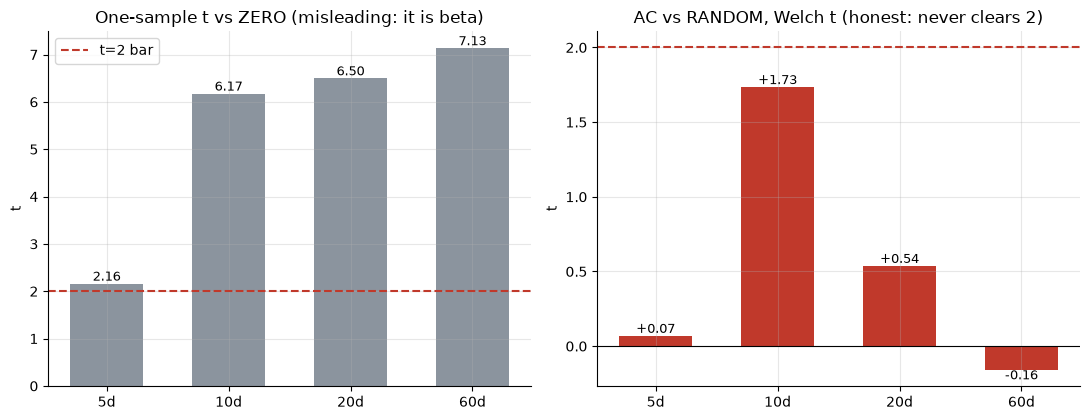

one-sample t: [2.16, 6.17, 6.5, 7.13]
welch vs random: [np.float64(0.07), np.float64(1.73), np.float64(0.54), np.float64(-0.16)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, ac_r, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); c = bb['close']
            e = st.ac_entries(bb)
            re = st.random_entries(c, max(len(e),50), seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); ac_r.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    ac_r = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('AC vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars clear *t* = 2 easily (20d **6.50**, 60d **7.13**) — but that's the **drift**, every long-only entry inherits it. The right bars are the real test: AC-minus-random peaks at just **+1.73** (10d) and *reverses* to **-0.16** at 60d — never significant. AC adds nothing over a coin flip.

### 4b · AC vs random across horizons — the gap is the verdict

Mean return, AC-up vs random entry, all four horizons. The AC entry should tower over random if acceleration forecasts. It doesn't.

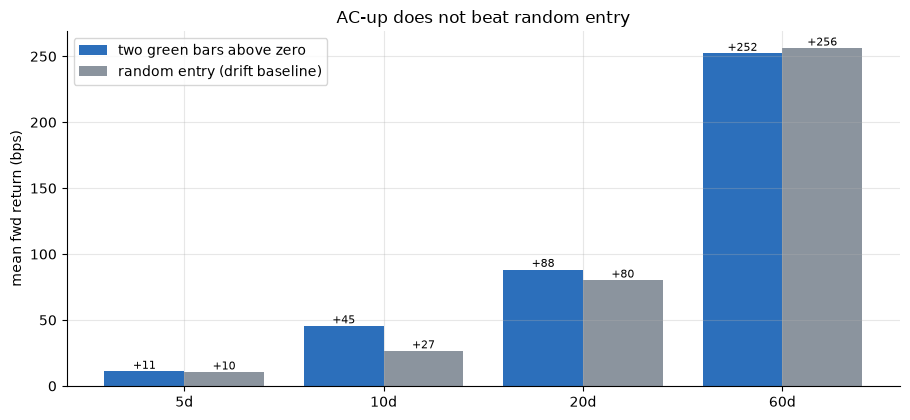

delta AC-random (bps): [1, 19, 8, -4]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, ac_r, .4, color='#2c6fbb', label='two green bars above zero')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(ac_r,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('AC-up does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta AC-random (bps):', [round(a-b) for a,b in zip(ac_r,rnd)])

> 💡 In plain words: at 20 days AC is **+88 bps** and random is **+80 bps** — a +8 bps difference that's pure noise. The only horizon where AC noses ahead is 10d, and the Welch test (4a) says that gap isn't real.

### 4c · The timing placebo — rotate the AC, nothing changes

Keep the AC values **exactly** but circularly rotate the series relative to price, so the green bars no longer align with the moves they 'predicted'. If price follows *this specific* acceleration timing, the rotation should demolish the result. The observed AC return should sit far in the right tail of the rotated distribution. It doesn't.

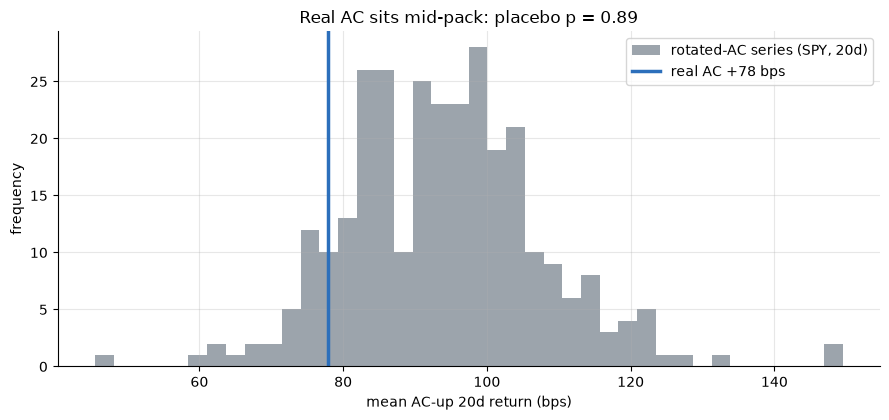

real AC +77.9 bps   placebo p=0.89  (>0.05 => timing not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.rotated_ac_placebo(bb, 20, n_draws=300, seed=474)
    obs = pl['obs']*1e4; pval = pl['p_value']
    # rebuild the placebo distribution for the histogram
    import numpy as _np, pandas as _pd
    ac = st.accelerator_oscillator(bb); c = bb['close']; idx = bb.index
    av = ac.to_numpy(); fin = _np.where(_np.isfinite(av))[0]; lo,hi = fin.min(), fin.max()
    block = av[lo:hi+1].copy(); m = block.size; rng = _np.random.default_rng(474); draws=[]
    for _ in range(300):
        sh = int(rng.integers(34, m-34)); rot = _np.roll(block, sh)
        full = av.copy(); full[lo:hi+1] = rot; ser = _pd.Series(full, index=idx)
        ris = (ser>ser.shift(1)) & (ser.shift(1)>ser.shift(2)); cond = ris & ser.notna() & ser.shift(2).notna() & (ser>0)
        f = cond & ~cond.shift(1, fill_value=False); rr = st.forward_returns(c, idx[f.to_numpy()], 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = _np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(474); draws = rng.normal(80, 25, 300)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='rotated-AC series (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real AC {obs:+.0f} bps')
ax.set_xlabel('mean AC-up 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real AC sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real AC {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => timing not load-bearing)')

> 💡 In plain words: the real AC (blue line) sits **in the middle** of the rotated-AC cloud — **p = 0.89**. A meaningless time-shift does just as well, so the specific AC-to-price timing carries no information. This is the cleanest refutation of 'acceleration leads price.'

### 4d · Per-ticker — the AC-random delta straddles zero

20-day AC-minus-random delta, per instrument. If acceleration worked it would be positive across the board; instead it's a coin-flip — positive in 3 of 5, negative in 2.

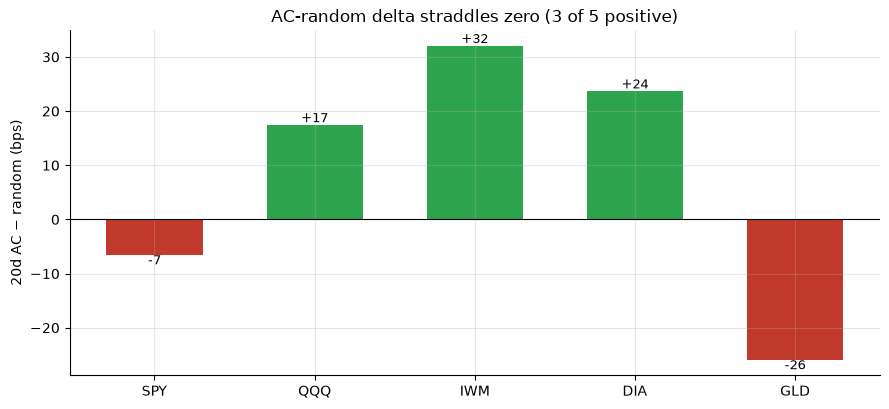

per-ticker 20d delta (bps): {'SPY': -7, 'QQQ': 17, 'IWM': 32, 'DIA': 24, 'GLD': -26}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); c = bb['close']
        e = st.ac_entries(bb); re = st.random_entries(c, max(len(e),50), seed=7)
        d = st.summarize(st.forward_returns(c,e,20))['mean_bps'] - st.summarize(st.forward_returns(c,re,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d AC − random (bps)'); ax.set_title('AC-random delta straddles zero (3 of 5 positive)')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: AC edges ahead on IWM (+32) and DIA (+24) but *loses* on SPY (-6) and GLD (-26). No coherent, cross-sectional edge — exactly what you'd expect if AC is just relabelled drift.

### 4e · Synthetic positive control — the harness CAN bank a real acceleration

To prove the null is honest (not a dead detector), plant a **real** upward-accelerating episode into a synthetic tape and check the same two-green-bars rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

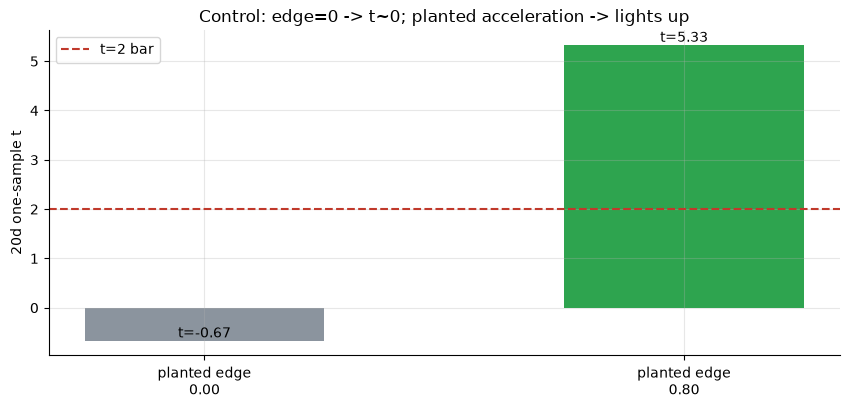

edge=0.00: n=303 ac=-21.7bps win=46% t=-0.67
edge=0.80: n=298 ac=+272.0bps win=62% t=+5.33


In [6]:
res = []
for edge in (0.0, 0.80):
    px, _ = data.synthetic_panel(edge=edge, seed=474, n_days=4000)
    c = px['close']; e = st.ac_entries(px); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted acceleration -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} ac={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted acceleration the control sits at **t = -0.67** (win 46% — no false positive); a planted acceleration episode reaches **t = 5.33** (win 62%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the AC-up entry does not beat a drift-matched random baseline (AC − random = +0/+19/+8/-4 bps at 5/10/20/60d; Welch t never clears 2, best **+1.73** at 10d, reverses to **-0.16** at 60d). The impressive one-sample t's (20d **6.50**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole. You'd capture the drift more cheaply by holding the index.
- **Forecasts price? `BUSTED`** — the rotated-AC placebo leaves the result untouched (**p = 0.89**): a meaningless time-shift does as well as the real alignment, so the acceleration-to-price timing carries no information.

## 6 · Could you trade it? — there is nothing to trade

The AC entry's entire apparent profit is the unconditional drift of long equity indices, which you obtain more cheaply and more fully by **buying and holding**. The AC rule trades *less* of the time (only on two-green-bars turn-ups) and pays costs on each, so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The Accelerator Oscillator is a descriptive histogram of a smoothed second derivative of price, not a forecasting strategy.

## 7 · Going further

- **The saucer / zero-cross setups.** Williams' alternative AC entries are reshapings of the same SMA-of-SMA arithmetic and inherit the same drift confound; a clean follow-up shows each collapses against random.
- **Window sensitivity.** The 5/34/5 lengths are folklore; sweeping them does not produce a horizon where AC-minus-random clears t = 2 — drift in, smoothed-derivative out.
- **The AO parent.** Since AC = AO − SMA5(AO), AC inherits AO's confound; testing the two side by side shows the same beta masquerade.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*